In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Instalar ComfyUI

In [ ]:
"""Módulo para la inicialización y configuración de dependencias del sistema.

Este script ejecuta comandos de terminal mediante el módulo `subprocess` para
preparar un entorno basado en Debian/Ubuntu. Actualiza los repositorios de
software e instala herramientas de red y librerías de renderizado gráfico base.

Ejemplo:
    El script está diseñado para ejecutarse directamente de forma secuencial::

        $ python setup_env.py
        Listo.

Raises:
    subprocess.CalledProcessError: Se lanza automáticamente si alguno de los
        comandos `apt-get` falla (devuelve un código de salida distinto de cero).
"""

import subprocess
import sys


def setup_environment():
    """Ejecuta los comandos de actualización e instalación del sistema.

    Utiliza `apt-get` para instalar herramientas de descarga (wget, aria2) y
    dependencias gráficas de bajo nivel (libgl1-mesa-glx, libglib2.0-0) que
    suelen ser requeridas por librerías de IA o visión computacional como OpenCV.
    """
    # Actualiza la lista de paquetes disponibles en los repositorios configurados.
    # El flag '-qq' (quite quiet) minimiza la salida en consola.
    subprocess.run(["apt-get", "update", "-qq"], check=True)

    # Instala los paquetes especificados sin solicitar confirmación al usuario.
    # Args de apt-get:
    #   -y: Responde "sí" automáticamente a las confirmaciones.
    #   -qq: Modo ultra silencioso.
    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "wget",
            "aria2",
            "libgl1-mesa-glx",
            "libglib2.0-0"
        ],
        check=True
    )

    print("Listo.")


if __name__ == "__main__":
    setup_environment()

Listo.


In [ ]:
"""Módulo para la descarga y configuración del entorno de ComfyUI.

Este script gestiona la obtención del código fuente de ComfyUI desde GitHub
(clonando o actualizando el repositorio) y la instalación de sus dependencias
de Python, asegurando la compatibilidad con CUDA para aceleración de hardware.
"""

import os
import subprocess
import sys


def setup_comfyui_repo(install_dir: str = "/content/ComfyUI") -> None:
    """Clona o actualiza el repositorio de ComfyUI e instala sus requerimientos.

    Verifica la existencia del directorio de destino. Si no existe, realiza un
    clonado superficial para minimizar el tiempo de descarga. Si ya existe,
    sincroniza los últimos cambios con `git pull`. Finalmente, instala las
    librerías de Python requeridas, optimizando para entornos de GPU.

    Args:
        install_dir: La ruta absoluta donde se alojará el repositorio de
            ComfyUI. Por defecto es "/content/ComfyUI".

    Raises:
        subprocess.CalledProcessError: Se lanza si las operaciones de `git`
            o la instalación mediante `pip` fallan.
    """
    # 1. Gestión del código fuente (GitHub)
    if not os.path.isdir(install_dir):
        # --depth 1 realiza un "shallow clone" (solo el último commit),
        # ahorrando tiempo de red y espacio en disco.
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/comfyanonymous/ComfyUI",
                install_dir
            ],
            check=True
        )
    else:
        # -C ejecuta el comando git como si estuviéramos dentro de install_dir
        subprocess.run(["git", "-C", install_dir, "pull"], check=True)

    # 2. Instalación de dependencias de Python
    # Se utiliza sys.executable para invocar de forma segura el pip asociado
    # al entorno virtual de Python actual, previniendo conflictos de rutas.
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "xformers!=0.0.18",
            "-r", f"{install_dir}/requirements.txt",
            "--extra-index-url", "https://download.pytorch.org/whl/cu121"
        ],
        check=True
    )

    print("Listo.")


if __name__ == "__main__":
    setup_comfyui_repo()

Listo.


In [ ]:
"""Módulo para la instalación y actualización de ComfyUI Manager.

Este script automatiza la descarga del gestor de nodos personalizados
(ComfyUI-Manager) desde su repositorio oficial en GitHub. Permite a los
usuarios instalar extensiones avanzadas (como IP-Adapter para la
preservación de identidad) directamente desde la interfaz gráfica.
"""

import os
import subprocess


def setup_comfyui_manager(
    custom_nodes_dir: str = "/content/ComfyUI/custom_nodes"
) -> None:
    """Instala o actualiza ComfyUI-Manager en el directorio especificado.

    Verifica si el directorio del gestor ya existe dentro de la carpeta de
    nodos personalizados (`custom_nodes`). Si no existe, clona el repositorio
    de GitHub. Si ya existe, actualiza el código existente con `git pull`.

    Args:
        custom_nodes_dir: La ruta absoluta al directorio `custom_nodes` de
            la instalación de ComfyUI. Por defecto es
            "/content/ComfyUI/custom_nodes".

    Raises:
        subprocess.CalledProcessError: Se lanza si los comandos de `git` fallan
            (por ejemplo, por problemas de red o de permisos en el sistema).
    """
    # Construye la ruta final de forma segura para cualquier sistema operativo
    manager_dir = os.path.join(custom_nodes_dir, "ComfyUI-Manager")

    if not os.path.isdir(manager_dir):
        print("Instalando ComfyUI Manager...")
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/ltdrdata/ComfyUI-Manager.git",
                manager_dir
            ],
            check=True
        )
    else:
        print("ComfyUI Manager ya está instalado. Actualizando...")
        # El argumento -C le dice a git que cambie a manager_dir antes de hacer 'pull'
        subprocess.run(["git", "-C", manager_dir, "pull"], check=True)

    print("Manager listo. Ahora podrás instalar IP-Adapter desde la interfaz visual.")


if __name__ == "__main__":
    setup_comfyui_manager()

Instalando ComfyUI Manager...
Manager listo. Ahora podrás instalar IP-Adapter desde la interfaz visual.


In [ ]:
"""Módulo para la persistencia de datos entre Google Colab y Google Drive.

Este script automatiza la creación de directorios en Google Drive para
almacenar los resultados y recursos de ComfyUI. Además, crea enlaces
simbólicos (symlinks) tanto para la carpeta de entrada (inputs) como la
de salida (outputs), permitiendo que ComfyUI lea y guarde directamente
en Drive en tiempo real.
"""

import os
import shutil


def setup_drive_storage(
    base_drive_dir: str = "/content/drive/MyDrive/Laboratorio4_ComfyUI",
    comfy_output_dir: str = "/content/ComfyUI/output",
    comfy_input_dir: str = "/content/ComfyUI/input"
) -> None:
    """Configura los directorios de Drive y enlaza entradas/salidas de ComfyUI.

    Crea las carpetas necesarias en Google Drive para los inputs (fotos
    de los integrantes) y outputs (resultados). Luego, reemplaza las carpetas
    predeterminadas de ComfyUI por enlaces simbólicos que apuntan
    directamente a las carpetas respectivas en Drive.

    Args:
        base_drive_dir: La ruta base en Google Drive donde se guardará
            todo el material del laboratorio.
        comfy_output_dir: La ruta absoluta a la carpeta de salida
            predeterminada dentro de la instalación de ComfyUI.
        comfy_input_dir: La ruta absoluta a la carpeta de entrada
            predeterminada dentro de la instalación de ComfyUI.

    Raises:
        OSError: Se lanza si hay problemas de permisos al crear directorios
            o al generar los enlaces simbólicos.
    """
    # 1. Definir y crear las carpetas en Google Drive
    drive_output = os.path.join(base_drive_dir, "resultados")
    drive_inputs = os.path.join(base_drive_dir, "fotos_integrantes")

    # exist_ok=True evita que el script falle si corres la celda más de una vez
    os.makedirs(drive_output, exist_ok=True)
    os.makedirs(drive_inputs, exist_ok=True)

    def link_folders(drive_target: str, comfy_link: str) -> None:
        """Función auxiliar para limpiar carpetas temporales y crear symlinks."""
        if os.path.exists(comfy_link) and not os.path.islink(comfy_link):
            shutil.rmtree(comfy_link)  # Borramos la carpeta original

        if not os.path.islink(comfy_link):
            os.symlink(drive_target, comfy_link)  # Creamos el puente

    # 2. Conectar la carpeta de salida (Outputs) hacia Drive
    link_folders(drive_output, comfy_output_dir)

    # 3. Conectar la carpeta de entrada (Inputs) hacia Drive
    link_folders(drive_inputs, comfy_input_dir)

    print("=========================================================")
    print("📁 ALMACENAMIENTO VINCULADO CON ÉXITO")
    print("=========================================================")
    print(f"📥 Entradas (Tus fotos): ComfyUI leerá automáticamente de:\n   {drive_inputs}")
    print(f"📤 Salidas (Resultados): Todo lo generado se guardará en:\n   {drive_output}")
    print("=========================================================")


if __name__ == "__main__":
    setup_drive_storage()

📁 ALMACENAMIENTO VINCULADO CON ÉXITO
📥 Entradas (Tus fotos): ComfyUI leerá automáticamente de:
   /content/drive/MyDrive/Laboratorio4_ComfyUI/fotos_integrantes
📤 Salidas (Resultados): Todo lo generado se guardará en:
   /content/drive/MyDrive/Laboratorio4_ComfyUI/resultados


# Descarga Realistic Vision V6.0

In [ ]:
"""Módulo para la descarga del Checkpoint Profesional (DreamShaper 8).

Sustituimos el modelo bloqueado por DreamShaper 8, un modelo de vanguardia
totalmente abierto, estable y altamente optimizado para fotorrealismo y
entornos de ciencia ficción.
"""

import os
import subprocess

def download_pro_checkpoint(
    models_dir: str = "/content/ComfyUI/models/checkpoints",
    model_filename: str = "DreamShaper_8_pruned.safetensors",
    model_url: str = "https://huggingface.co/Lykon/DreamShaper/resolve/main/DreamShaper_8_pruned.safetensors"
) -> None:
    """Descarga el Checkpoint profesional usando aria2c."""

    os.makedirs(models_dir, exist_ok=True)
    model_file = os.path.join(models_dir, model_filename)

    if not os.path.isfile(model_file):
        print(f"🚀 Descargando Modelo Profesional: {model_filename}...")
        subprocess.run(
            [
                "aria2c",
                "-x", "16",
                "-s", "16",
                "-k", "1M",
                "--console-log-level=warn",
                "-d", models_dir,
                "-o", model_filename,
                model_url
            ],
            check=True
        )
        print("✅ Descarga exitosa.")
    else:
        print(f"⭐ El modelo {model_filename} ya está listo para usar.")

if __name__ == "__main__":
    download_pro_checkpoint()

⭐ El modelo DreamShaper_8_pruned.safetensors ya está listo para usar.


In [ ]:
"""Módulo de instalación forzada para IP-Adapter Plus y sus modelos.

Este script clona directamente el repositorio oficial del nodo y utiliza
descargas multihilo para obtener los pesos neuronales exactos requeridos
para la preservación de identidad (Face ID) en modelos de arquitectura SD 1.5.
"""

import os
import subprocess

def force_install_ipadapter():
    """Clona el nodo personalizado y descarga los modelos visuales requeridos."""

    # 1. Clonar el repositorio oficial de IP-Adapter
    custom_nodes_dir = "/content/ComfyUI/custom_nodes"
    ip_adapter_dir = os.path.join(custom_nodes_dir, "ComfyUI_IPAdapter_plus")

    if not os.path.exists(ip_adapter_dir):
        print("📥 Clonando repositorio de IP-Adapter Plus...")
        subprocess.run(["git", "clone", "https://github.com/cubiq/ComfyUI_IPAdapter_plus.git", ip_adapter_dir], check=True)
    else:
        print("🔄 Repositorio IP-Adapter ya clonado. Actualizando...")
        subprocess.run(["git", "-C", ip_adapter_dir, "pull"], check=True)

    # 2. Crear las carpetas de modelos donde IP-Adapter buscará los archivos
    clip_vision_dir = "/content/ComfyUI/models/clip_vision"
    ip_models_dir = "/content/ComfyUI/models/ipadapter"
    os.makedirs(clip_vision_dir, exist_ok=True)
    os.makedirs(ip_models_dir, exist_ok=True)

    # 3. Descargar el modelo CLIP Vision (El "Ojo" que lee la foto original)
    clip_model = os.path.join(clip_vision_dir, "CLIP-ViT-H-14-laion2B-s32B-b79K.safetensors")
    if not os.path.exists(clip_model):
        print("👁️ Descargando modelo CLIP Vision (5GB aprox)...")
        subprocess.run([
            "aria2c", "-x", "16", "-s", "16",
            "-d", clip_vision_dir, "-o", "CLIP-ViT-H-14-laion2B-s32B-b79K.safetensors",
            "https://huggingface.co/h94/IP-Adapter/resolve/main/models/image_encoder/model.safetensors"
        ], check=True)

    # 4. Descargar el modelo específico de Rostros para SD 1.5
    face_model = os.path.join(ip_models_dir, "ip-adapter-plus-face_sd15.safetensors")
    if not os.path.exists(face_model):
        print("👤 Descargando pesos de preservación facial...")
        subprocess.run([
            "aria2c", "-x", "16", "-s", "16",
            "-d", ip_models_dir, "-o", "ip-adapter-plus-face_sd15.safetensors",
            "https://huggingface.co/h94/IP-Adapter/resolve/main/models/ip-adapter-plus-face_sd15.safetensors"
        ], check=True)

    print("✅ ¡Instalación completada a nivel de sistema operativo!")

if __name__ == "__main__":
    force_install_ipadapter()

🔄 Repositorio IP-Adapter ya clonado. Actualizando...
✅ ¡Instalación completada a nivel de sistema operativo!


In [ ]:
import os
import subprocess

def download_standard_ipadapter():
    IPADAPTER_DIR = "/content/ComfyUI/models/ipadapter"
    os.makedirs(IPADAPTER_DIR, exist_ok=True)

    # Descargar el modelo Standard para SD 1.5
    std_url = "https://huggingface.co/h94/IP-Adapter/resolve/main/models/ip-adapter_sd15.safetensors"
    std_dest = os.path.join(IPADAPTER_DIR, "ip-adapter_sd15.safetensors")

    if not os.path.exists(std_dest):
        print("📥 Descargando modelo IP-Adapter Standard...")
        subprocess.run(["aria2c", "-x", "16", "-s", "16", "-d", IPADAPTER_DIR, "-o", "ip-adapter_sd15.safetensors", std_url], check=True)
    else:
        print("👍 El modelo Standard ya existe.")

download_standard_ipadapter()

📥 Descargando modelo IP-Adapter Standard...


# Iniciar ComfyUI

Deberás hacer click en el URL generado:

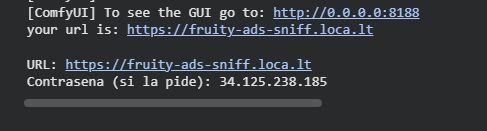



Luego, coloca el IP que se ve al inicio de la pagina en el cuadro. Finalmente clic en Continue:
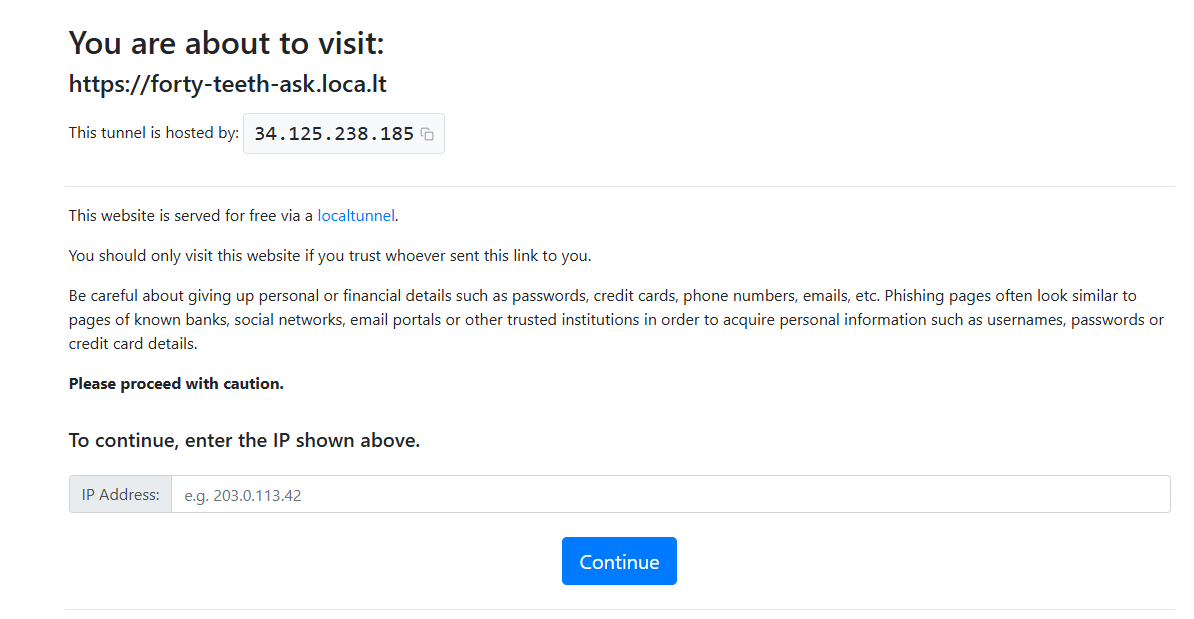

Espera unos segundos podrás acceder a ComfyUI

In [ ]:
"""Módulo para la ejecución del servidor ComfyUI y su exposición a internet.

Este script arranca el servidor local de ComfyUI en un proceso secundario,
monitorea sus registros en tiempo real para confirmar su inicialización, y
luego crea un túnel público utilizando `localtunnel`. Además, gestiona la
obtención de la IP pública del servidor para eludir las pantallas de
advertencia de seguridad del túnel.
"""

import re
import subprocess
import sys
import threading
import time


def start_comfyui_and_tunnel(
    comfyui_dir: str = "/content/ComfyUI",
    port: int = 8188,
    startup_timeout: int = 120
) -> None:
    """Arranca ComfyUI y establece un túnel de acceso público.

    Ejecuta el servidor de forma asíncrona usando `subprocess.Popen`. Utiliza
    un hilo (Thread) para leer la salida estándar hasta detectar que el servidor
    está listo. Luego, obtiene la IP del contenedor de Colab e inicia `localtunnel`
    para proporcionar una URL accesible desde cualquier navegador.

    Args:
        comfyui_dir: Directorio base de la instalación de ComfyUI.
        port: Puerto local donde ComfyUI escuchará las peticiones (8188 por defecto).
        startup_timeout: Segundos máximos a esperar para que arranque el servidor.

    Raises:
        subprocess.CalledProcessError: Si falla la instalación de localtunnel.
    """
    # 1. Instalar localtunnel globalmente mediante Node.js (npm)
    subprocess.run(
        ["npm", "install", "-g", "localtunnel"],
        check=True,
        capture_output=True
    )

    # 2. Iniciar ComfyUI en un proceso no bloqueante (Popen)
    # Escucha en 0.0.0.0 para aceptar conexiones fuera del entorno localhost estricto
    comfy_proc = subprocess.Popen(
        ["python", "main.py", "--listen", "0.0.0.0", "--port", str(port)],
        cwd=comfyui_dir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    # Evento de sincronización para saber cuándo ComfyUI terminó de cargar
    ready_event = threading.Event()

    def log_comfyui() -> None:
        """Lee e imprime los logs de ComfyUI; avisa cuando está listo."""
        for line in comfy_proc.stdout:
            print("[ComfyUI]", line.rstrip())
            # Palabras clave que indican que la interfaz web ya está activa
            if "To see the GUI go to:" in line or "Starting server" in line:
                ready_event.set()

    # Iniciar el monitor de logs en un hilo secundario (daemon=True permite
    # que el hilo muera si el programa principal termina)
    threading.Thread(target=log_comfyui, daemon=True).start()

    print("Esperando que ComfyUI arranque (esto puede tomar un momento si carga modelos)...")
    ready_event.wait(timeout=startup_timeout)
    time.sleep(2)  # Margen de seguridad para que el puerto se asiente

    # 3. Obtener la IP pública del contenedor
    # Localtunnel ahora exige introducir la IP del host web como medida anti-phishing
    ip_result = subprocess.run(
        ["curl", "-s", "https://api.ipify.org"],
        capture_output=True,
        text=True
    )
    server_ip = ip_result.stdout.strip()

    # 4. Iniciar localtunnel
    tunnel_proc = subprocess.Popen(
        ["lt", "--port", str(port)],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    # Leer la salida de localtunnel para capturar la URL generada
    for line in tunnel_proc.stdout:
        print(line.rstrip())
        # Busca una URL que siga el patrón de localtunnel usando expresiones regulares
        match = re.search(r'https://[\w\-]+\.loca\.lt', line)
        if match:
            print(f"\n==================================================")
            print(f"🌍 URL de ComfyUI: {match.group(0)}")
            print(f"🔑 Contraseña (Endpoint IP): {server_ip}")
            print(f"==================================================\n")
            break

    # 5. Bucle principal y cierre limpio
    try:
        # Mantiene la celda ejecutándose eternamente hasta que presiones "Stop"
        tunnel_proc.wait()
    except KeyboardInterrupt:
        # Si detienes la celda, cierra los procesos para liberar memoria y puertos
        print("\nDeteniendo servidor y túnel...")
        tunnel_proc.terminate()
        comfy_proc.terminate()


if __name__ == "__main__":
    start_comfyui_and_tunnel()

Esperando que ComfyUI arranque (esto puede tomar un momento si carga modelos)...
[ComfyUI] [START] Security scan
[ComfyUI] [DONE] Security scan
[ComfyUI] ## ComfyUI-Manager: installing dependencies done.
[ComfyUI] ** ComfyUI startup time: 2026-04-20 05:54:49.420
[ComfyUI] ** Platform: Linux
[ComfyUI] ** Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
[ComfyUI] ** Python executable: /usr/bin/python3
[ComfyUI] ** ComfyUI Path: /content/ComfyUI
[ComfyUI] ** ComfyUI Base Folder Path: /content/ComfyUI
[ComfyUI] ** User directory: /content/ComfyUI/user
[ComfyUI] ** ComfyUI-Manager config path: /content/ComfyUI/user/__manager/config.ini
[ComfyUI] ** Log path: /content/ComfyUI/user/comfyui.log
[ComfyUI] 
[ComfyUI] Prestartup times for custom nodes:
[ComfyUI]    7.2 seconds: /content/ComfyUI/custom_nodes/ComfyUI-Manager
[ComfyUI] 
[ComfyUI] WARNING: You need pytorch with cu130 or higher to use optimized CUDA operations.
[ComfyUI] Found comfy_kitchen backend cuda: {'available'